In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_boston




In [4]:
boston = load_boston()

# 2. Extract arrays into the DataFrame constructor
df = pd.DataFrame(data = boston.data, columns= boston.feature_names)

# 3. (Optional) Append target prices column
df["price"] = boston.target

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


Text(0, 0.5, 'Actual Prices')

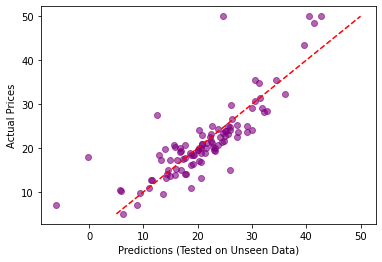

In [21]:
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score, cross_val_predict  #it is only used to judge the pipeline we have created 
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split  

Pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model",LinearRegression())
])

X , y = load_boston(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



Pipe.fit(X_train,y_train)

pred = Pipe.predict(X_test)

plt.scatter(pred, y_test, color= "purple", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")

plt.xlabel("Predictions (Tested on Unseen Data)")
plt.ylabel("Actual Prices")


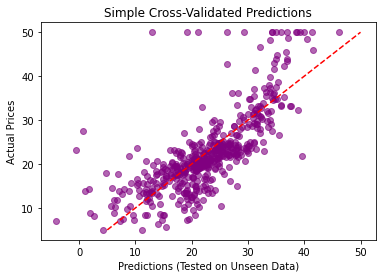

In [31]:
# to tell how efficient our model is we use cross_val_predict


# cv=5 splits the data 5 times automatically behind the scenes
cv_pred = cross_val_predict(Pipe, X, y, cv=5)

# 5. PLOT THE RESULTS
plt.scatter(cv_pred, y, color="purple", alpha=0.6)

# A red line showing where "perfect predictions" would land
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")

plt.xlabel("Predictions (Tested on Unseen Data)")
plt.ylabel("Actual Prices")
plt.title("Simple Cross-Validated Predictions")
plt.show()